# Adult Census Income Prediction
### Assignment: Predicting whether an individual's income exceeds $50,000/year

**Dataset:** Adult Census Income Dataset (UCI / Kaggle)
**Tasks:** Dataset Understanding → Data Cleaning → Feature Engineering → Model Building → Performance Evaluation


## Task 1: Dataset Understanding (10 Marks)

In [1]:
# Import the libraries we'll need throughout the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look a bit nicer by default
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Load the dataset
df = pd.read_csv('adult.csv')

# Take a first look at the data
df.head()


   age workclass  fnlwgt  ... hours.per.week  native.country income
0   90         ?   77053  ...             40   United-States  <=50K
1   82   Private  132870  ...             18   United-States  <=50K
2   66         ?  186061  ...             40   United-States  <=50K
3   54   Private  140359  ...             40   United-States  <=50K
4   41   Private  264663  ...             40   United-States  <=50K

[5 rows x 15 columns]

In [2]:
# Basic shape and structure of the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print()
print("Column names and data types:")
print(df.dtypes)


Number of rows: 32561
Number of columns: 15

Column names and data types:
age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object
age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object


**Observation:** The dataset has 32,561 rows and 15 columns. There are 6 numeric columns
(age, fnlwgt, education.num, capital.gain, capital.loss, hours.per.week) and 9 categorical/text
columns (workclass, education, marital.status, occupation, relationship, race, sex, native.country,
and the target `income`).

In [3]:
# Summary statistics for the numeric columns
df.describe().round(2)


            age      fnlwgt  ...  capital.loss  hours.per.week
count  32561.00    32561.00  ...      32561.00        32561.00
mean      38.58   189778.37  ...         87.30           40.44
std       13.64   105549.98  ...        402.96           12.35
min       17.00    12285.00  ...          0.00            1.00
25%       28.00   117827.00  ...          0.00           40.00
50%       37.00   178356.00  ...          0.00           40.00
75%       48.00   237051.00  ...          0.00           45.00
max       90.00  1484705.00  ...       4356.00           99.00

[8 rows x 6 columns]

In [4]:
# Look more closely at the categorical columns - what values do they take, and how often?
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)
print()
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


Categorical columns: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']

--- workclass ---
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

--- education ---
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

--- marital.status ---
marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Wi

**Observation:** Several categorical columns contain a `'?'` value, which is how this dataset
encodes *missing* data (this is NOT a real category, e.g. `workclass = '?'` just means we don't
know the person's workclass). We will need to handle this properly in the Data Cleaning step,
since a naive `.isnull().sum()` will NOT catch these — pandas reads `'?'` as a normal string,
not as NaN.

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

income
<=50K    75.92
>50K     24.08
Name: proportion, dtype: float64 %


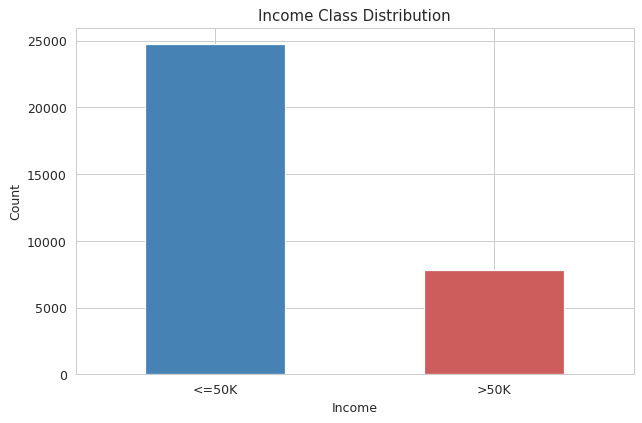

In [5]:
# Check the target variable distribution - is the dataset balanced?
print(df['income'].value_counts())
print()
print(df['income'].value_counts(normalize=True).round(4) * 100, "%")

df['income'].value_counts().plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Income Class Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


**Observation:** The target is *imbalanced* — about 76% of people earn `<=50K` and only 24% earn
`>50K`. This matters later: plain accuracy can be misleading on imbalanced data, which is exactly
why the assignment also asks for Precision, Recall, F1, and ROC-AUC, not just Accuracy.

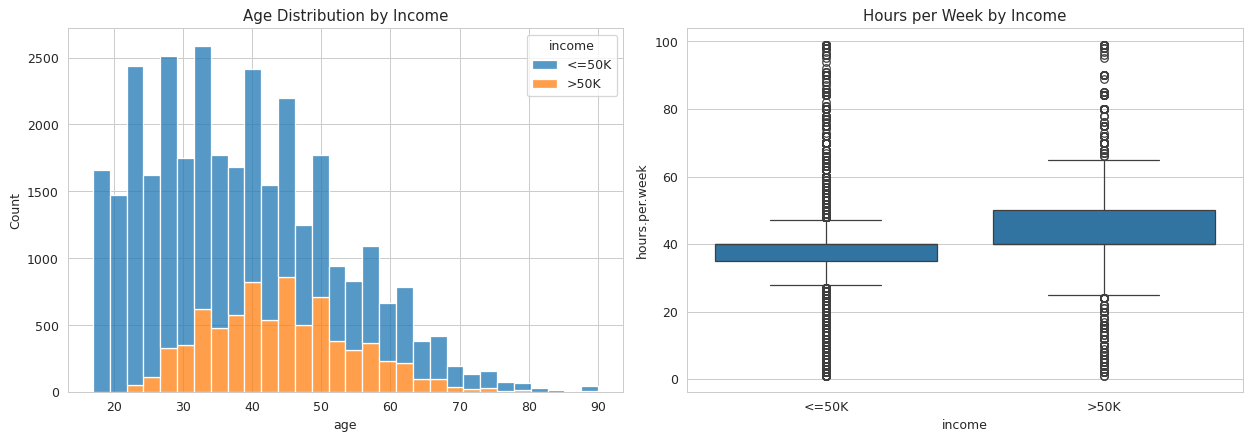

In [6]:
# Visualize a few relationships to understand the data better

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by income
sns.histplot(data=df, x='age', hue='income', multiple='stack', ax=axes[0], bins=30)
axes[0].set_title('Age Distribution by Income')

# Hours per week by income
sns.boxplot(data=df, x='income', y='hours.per.week', ax=axes[1])
axes[1].set_title('Hours per Week by Income')

plt.tight_layout()
plt.show()


**Observation:** People earning `>50K` tend to be a bit older on average and tend to work more
hours per week, which makes intuitive sense (more senior/full-time roles correlate with
higher pay).

In [7]:
# Check for fully duplicated rows and missing values reported by pandas natively
print("Duplicate rows:", df.duplicated().sum())
print()
print("Null values (pandas' own NaN detection):")
print(df.isnull().sum())


Duplicate rows: 24

Null values (pandas' own NaN detection):
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


**Summary of Task 1:**
- 32,561 rows, 15 columns (14 features + 1 target).
- Mix of numeric and categorical features describing demographics and employment.
- Target `income` is imbalanced (~76% / 24%).
- No NaNs by pandas' default check, BUT `workclass`, `occupation`, and `native.country`
  contain `'?'` placeholders that represent missing data.
- 24 fully duplicated rows exist and should be removed.


## Task 2: Data Cleaning (20 Marks)

In [8]:
# Step 1: Strip any leading/trailing whitespace from string columns
# (Common issue in this dataset - e.g. " Private" instead of "Private")
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip()


In [9]:
# Step 2: Replace '?' placeholders with proper NaN values so pandas can detect them as missing
df.replace('?', np.nan, inplace=True)

print("Missing values after converting '?' to NaN:")
missing = df.isnull().sum()
print(missing[missing > 0])
print()
print("Percentage missing:")
print((missing[missing > 0] / len(df) * 100).round(2))


Missing values after converting '?' to NaN:
workclass         1836
occupation        1843
native.country     583
dtype: int64

Percentage missing:
workclass         5.64
occupation        5.66
native.country    1.79
dtype: float64
workclass         5.64
occupation        5.66
native.country    1.79
dtype: float64


In [10]:
# Step 3: Remove duplicate rows
print("Duplicates before removal:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Duplicates before removal: 24
Shape after removing duplicates: (32537, 15)
Shape after removing duplicates: (32537, 15)


In [11]:
# Step 4: Handle missing values
# All 3 affected columns (workclass, occupation, native.country) are categorical,
# and the missing percentage is small (<6%), so imputing with the MODE (most frequent
# category) is a reasonable, simple strategy that won't distort the distribution much.

for col in ['workclass', 'occupation', 'native.country']:
    mode_value = df[col].mode()[0]
    print(f"Filling missing '{col}' with mode: '{mode_value}'")
    df[col] = df[col].fillna(mode_value)

print()
print("Total missing values remaining:", df.isnull().sum().sum())


Filling missing 'workclass' with mode: 'Private'
Filling missing 'occupation' with mode: 'Prof-specialty'
Filling missing 'native.country' with mode: 'United-States'

Total missing values remaining: 0
Total missing values remaining: 0


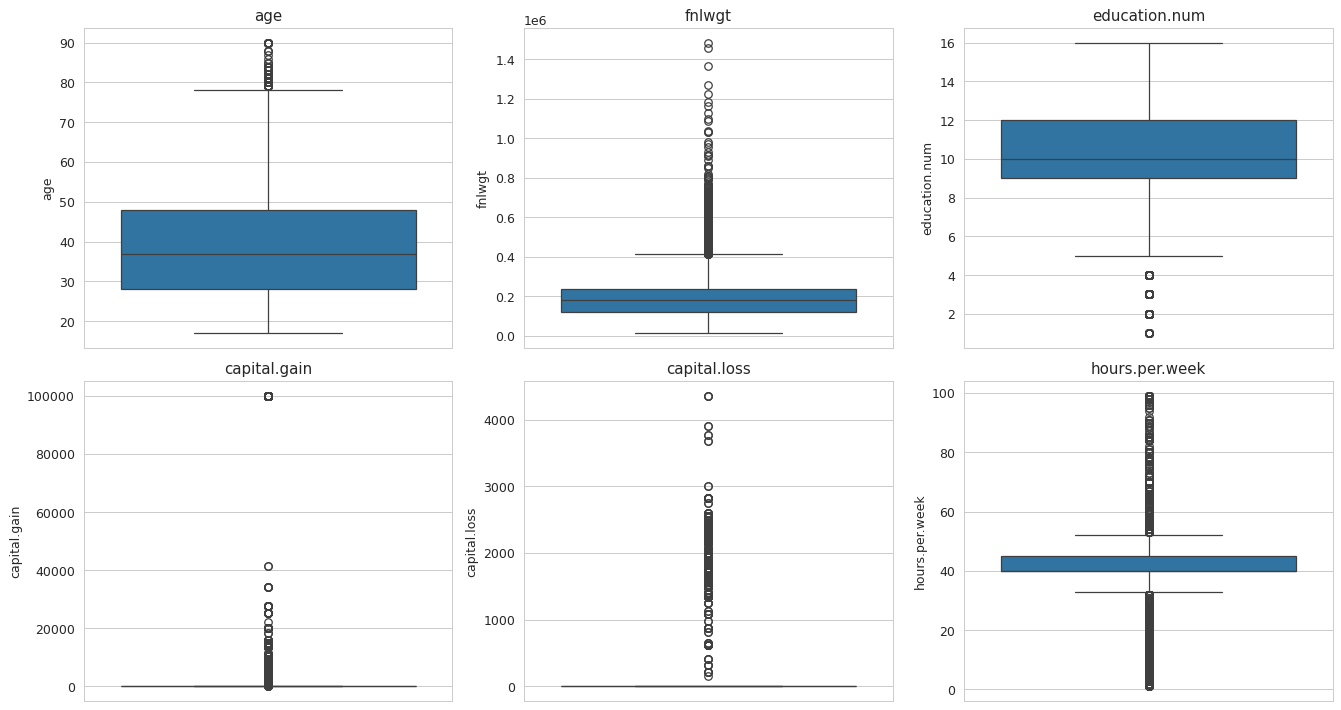

In [12]:
# Step 5: Check for outliers in numeric columns using boxplots
numeric_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Note on outliers:** `capital.gain` and `capital.loss` show many points at 0 with a long tail
of high values — this is *expected* behavior (most people report no capital gains/losses in a
given year) rather than data-entry errors, so we won't remove these as outliers. Instead, we'll
engineer a feature for "has capital gain/loss" in Task 3, since the raw skew makes the column
hard for some models (like KNN/SVM) to use directly. `age` and `hours.per.week` look reasonable
and within plausible real-world ranges, so no rows need to be dropped for them.

In [13]:
# Save the cleaned dataset
df.to_csv('adult_cleaned.csv', index=False)
print("Cleaned dataset shape:", df.shape)
df.head()


   age workclass  fnlwgt  ... hours.per.week  native.country income
0   90   Private   77053  ...             40   United-States  <=50K
1   82   Private  132870  ...             18   United-States  <=50K
2   66   Private  186061  ...             40   United-States  <=50K
3   54   Private  140359  ...             40   United-States  <=50K
4   41   Private  264663  ...             40   United-States  <=50K

[5 rows x 15 columns]

Cleaned dataset shape: (32537, 15)


**Summary of Task 2:**
- Stripped whitespace from all text columns.
- Converted `'?'` placeholders to proper `NaN`.
- Removed 24 duplicate rows.
- Imputed missing `workclass`, `occupation`, `native.country` with the mode (most frequent value).
- Inspected numeric columns for outliers; kept `capital.gain`/`capital.loss` skew as-is since it
  reflects real-world behavior, to be addressed via feature engineering instead.
- Final cleaned shape: 32,537 rows × 15 columns.


## Task 3: Feature Engineering (15 Marks)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('adult_cleaned.csv')

# 1) Drop 'fnlwgt' - this is a census *sampling weight* used by the Census Bureau for
#    population estimation. It has no real predictive relationship with a person's income
#    and including it would just add noise.
df = df.drop(columns=['fnlwgt'])

# 2) Encode the target variable as binary: 1 = '>50K', 0 = '<=50K'
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# 3) 'native.country' has 41 distinct values but the USA dominates (~90% of rows).
#    Too many sparse categories would explode the feature space after one-hot encoding
#    and most countries have very few samples to learn from, so we simplify to a
#    binary US / Other feature instead.
df['native.country'] = df['native.country'].apply(lambda x: 'United-States' if x == 'United-States' else 'Other')

# 4) 'capital.gain' and 'capital.loss' are extremely skewed (mostly zero, with a few huge values).
#    We create simple binary flags to capture "did this person have ANY capital gain/loss"
#    in addition to keeping the raw numeric columns.
df['has_capital_gain'] = (df['capital.gain'] > 0).astype(int)
df['has_capital_loss'] = (df['capital.loss'] > 0).astype(int)

# 5) 'education' (text) and 'education.num' (numeric) encode the exact same information
#    (e.g. 'Bachelors' <-> 12). We keep only the numeric version since it's already
#    ordinal and ready for modeling, and drop the redundant text column.
df = df.drop(columns=['education'])

df.head()


   age workclass  education.num  ... income has_capital_gain has_capital_loss
0   90   Private              9  ...      0                0                1
1   82   Private              9  ...      0                0                1
2   66   Private             10  ...      0                0                1
3   54   Private              4  ...      0                0                1
4   41   Private             10  ...      0                0                1

[5 rows x 15 columns]

In [15]:
# 6) One-hot encode the remaining categorical (nominal) columns.
# We use drop_first=True to avoid the "dummy variable trap" (multicollinearity).
categorical_cols = ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Number of features after encoding:", df_encoded.shape[1] - 1)  # -1 to exclude target
df_encoded.head()


   age  education.num  ...  sex_Male  native.country_United-States
0   90              9  ...     False                          True
1   82              9  ...     False                          True
2   66             10  ...     False                          True
3   54              4  ...     False                          True
4   41             10  ...     False                          True

[5 rows x 45 columns]

Number of features after encoding: 44


In [16]:
# 7) Split features (X) and target (y)
X = df_encoded.drop(columns=['income'])
y = df_encoded['income']

# 8) Train/test split - stratify on y to preserve the 76/24 class balance in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (26029, 44)
Test set: (6508, 44)
Test set: (6508, 44)


In [17]:
# 9) Scale the numeric features. This matters a lot for distance-based models (KNN, SVM)
# and for Logistic Regression's gradient-based optimizer, though it makes little difference
# for tree-based models (Decision Tree / Random Forest), which we'll fit on the same scaled
# data for a consistent comparison.

numeric_cols = ['age', 'education.num', 'capital.gain', 'capital.loss',
                'hours.per.week', 'has_capital_gain', 'has_capital_loss']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])  # transform only, never re-fit on test!

X_train_scaled.head()


            age  education.num  ...  sex_Male  native.country_United-States
25252 -1.285119      -0.031109  ...      True                          True
3349   0.183261       0.357626  ...      True                          True
4584  -1.064862      -0.419844  ...     False                          True
7003   1.504803      -0.419844  ...     False                          True
882   -0.257253      -0.419844  ...      True                         False

[5 rows x 44 columns]

**Summary of Task 3:**
- Dropped `fnlwgt` (irrelevant sampling weight) and `education` (redundant with `education.num`).
- Encoded `income` as binary (1 = `>50K`, 0 = `<=50K`).
- Simplified `native.country` into US / Other to avoid sparse categories.
- Added `has_capital_gain` / `has_capital_loss` binary flags to handle the heavy skew in those columns.
- One-hot encoded remaining categorical features (44 final features).
- Performed an 80/20 stratified train-test split.
- Standardized numeric features using `StandardScaler` (fit on train, applied to test).


## Task 4: Model Building (30 Marks)
### Classification Algorithms

We train five different classifiers on the same train/test split so that we can fairly
compare them in Task 5:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Define all 5 models with reasonable hyperparameters.
# max_depth is set for the tree-based models to help prevent overfitting on this dataset.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

# Train (fit) every model on the scaled training data
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

print("\nAll models trained successfully!")


Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training KNN...
Training SVM...

All models trained successfully!

All models trained successfully!


**Note:** SVM training can take noticeably longer than the others because its training time
scales poorly with the number of rows (this dataset has ~26,000 training rows). This is normal
and expected — just give it a moment to finish.

## Task 5: Performance Evaluation (15 Marks)

In [19]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

# Compute all 5 metrics for every model on the held-out TEST set
results = []
predictions = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of the positive class ('>50K')

    predictions[name] = (y_pred, y_proba)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, prec, rec, f1, roc_auc])

results_df = pd.DataFrame(results, columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])
results_df = results_df.round(4)
results_df


             Algorithm  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8520     0.7403  0.5944    0.6594   0.9021
1        Decision Tree    0.8526     0.7659  0.5593    0.6465   0.8888
2        Random Forest    0.8569     0.7826  0.5625    0.6545   0.9116
3                  KNN    0.8411     0.6814  0.6397    0.6599   0.8885
4                  SVM    0.8513     0.7560  0.5651    0.6467   0.8892

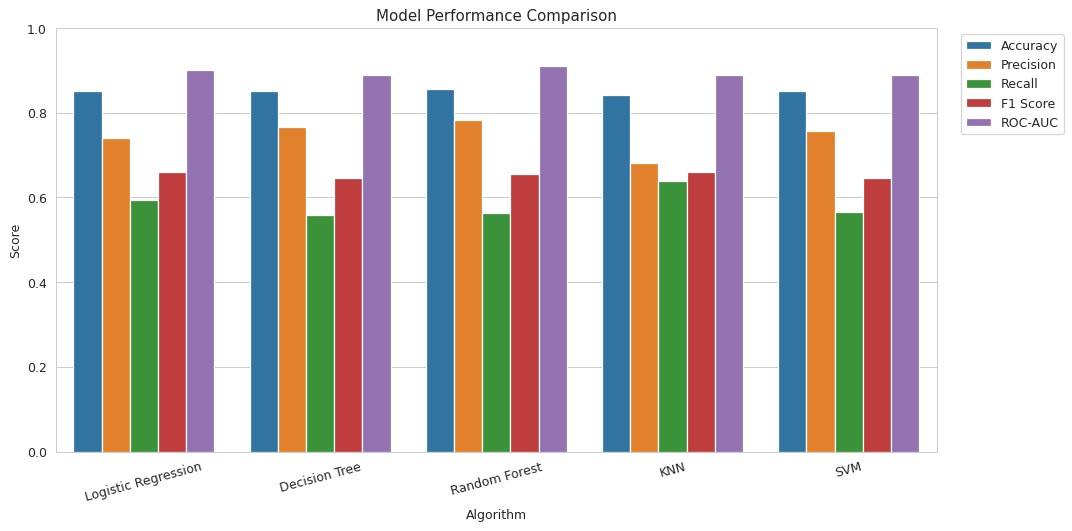

In [20]:
# Visualize the comparison as a grouped bar chart
results_melted = results_df.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Algorithm', y='Score', hue='Metric')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


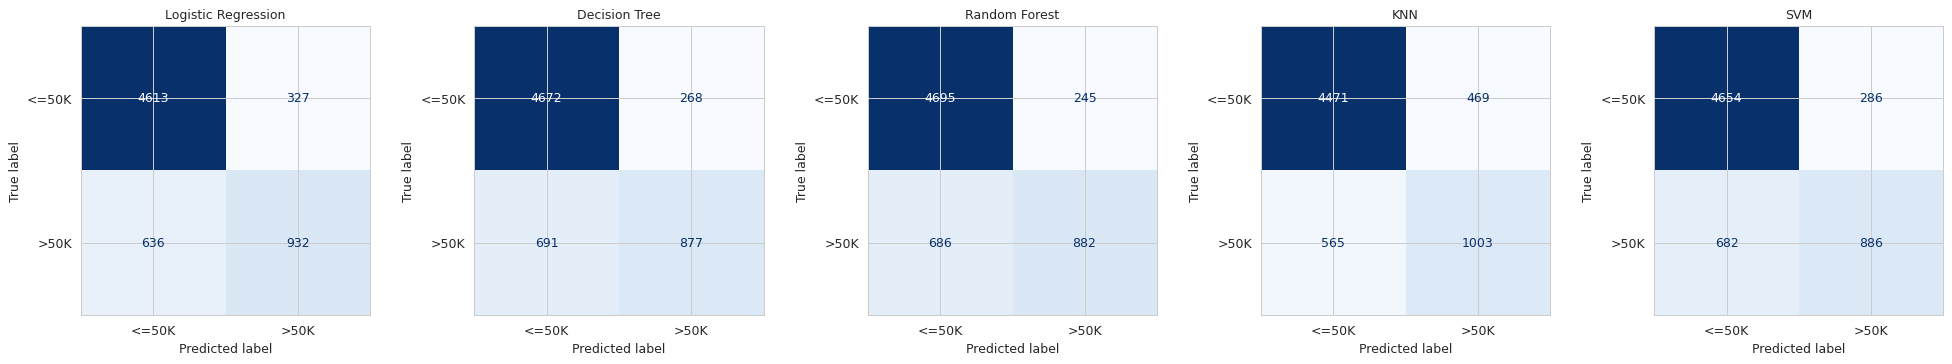

In [21]:
# Plot confusion matrices for all 5 models side-by-side
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred, _ = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()


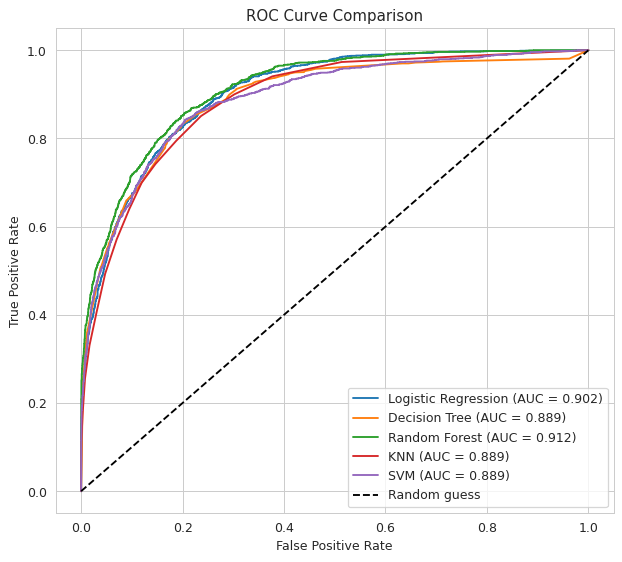

In [22]:
# Plot ROC curves for all 5 models on one chart for direct comparison
plt.figure(figsize=(8, 7))
for name, model in trained_models.items():
    _, y_proba = predictions[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()


### Final Results Table

| Algorithm | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.8520 | 0.7403 | 0.5944 | 0.6594 | 0.9021 |
| Decision Tree | 0.8526 | 0.7659 | 0.5593 | 0.6465 | 0.8888 |
| Random Forest | 0.8569 | 0.7826 | 0.5625 | 0.6545 | 0.9116 |
| KNN | 0.8411 | 0.6814 | 0.6397 | 0.6599 | 0.8885 |
| SVM | 0.8513 | 0.7560 | 0.5651 | 0.6467 | 0.8892 |

### Discussion

- **Random Forest** achieves the best **Accuracy (85.7%)** and the best **ROC-AUC (0.912)**,
  meaning it ranks/separates the two income classes most reliably overall. Ensembling many
  decision trees reduces overfitting compared to a single Decision Tree while still capturing
  non-linear relationships in the data.
- **KNN** has the highest **Recall (0.640)** — it catches more of the actual `>50K` earners
  than other models — but at the cost of the lowest **Precision (0.681)**, meaning it also
  produces more false positives.
- **Decision Tree** and **Random Forest** have the strongest **Precision** (0.766 and 0.783),
  meaning when they predict `>50K`, they are right most often, but they sacrifice some Recall.
- **Logistic Regression**, despite being the simplest model, performs very competitively —
  close to Random Forest on ROC-AUC (0.902 vs 0.912) — suggesting the relationship between
  these features and income is largely close to linear/log-linear, or that a clean,
  well-engineered feature set narrows the performance gap between simple and complex models.
- All models sit in a fairly tight accuracy band (84.1%–85.7%), and all underperform on Recall
  relative to Precision — a direct consequence of the **76/24 class imbalance**: every model
  finds it easier to correctly spot the majority `<=50K` class than the minority `>50K` class.

**Overall recommendation:** If overall predictive power and ranking quality matter most
(e.g. for credit-scoring-style ranking), **Random Forest** is the best choice here. If catching
as many high earners as possible matters more than precision (e.g. targeted marketing where
false positives are cheap), **KNN** would be preferable despite its lower accuracy.
